# Spectral Continuation, Autocorrelation, and Growth Metrics

Nine analyses in three directions, exploring the Collatz family $T(n) = (xn+y)/2^v$.

In [1]:
import contextlib
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pade
from scipy.linalg import eig

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

PLOT_DIR = os.path.join(os.getcwd(), "..", "analysis")

In [2]:
# ---------------------------------------------------------------------------
# Helpers (redefined locally to avoid import-time execution)
# ---------------------------------------------------------------------------


def syracuse_general(n, x, y):
    """Syracuse map: odd n -> (xn + y) / 2^v. Returns (result, v)."""
    val = x * n + y
    if val <= 0:
        return None, 0
    v = 0
    while val % 2 == 0:
        val //= 2
        v += 1
    return val, v


def trajectory_general(n, x, y, max_steps=2000):
    """Trajectory of odd n under the (x, y) Syracuse map."""
    values = [n]
    vs = []
    visited = {n: 0}
    for step in range(1, max_steps + 1):
        result, v = syracuse_general(n, x, y)
        if result is None:
            return values, vs, "non-positive"
        vs.append(v)
        if result in visited:
            values.append(result)
            return values, vs, "cycle"
        if result > n * 1000 and step > 50:
            values.append(result)
            return values, vs, "diverged"
        visited[result] = step
        values.append(result)
        n = result
    return values, vs, "diverged"


def collatz_full(n, x, y, max_steps=100000):
    """Full Collatz trajectory (even steps included) for T(n) = xn+y."""
    trajectory = [n]
    visited = {n}
    for _ in range(max_steps):
        if n % 2 == 0:
            n = n // 2
        else:
            val = x * n + y
            if val <= 0:
                break
            n = val
        trajectory.append(n)
        if n == 1:
            break
        if n in visited:
            break
        if n > 10**18:
            break
        visited.add(n)
    return trajectory


def v_sequence_general(n, x, y, max_steps=1000):
    """v-sequence for the (x, y) Syracuse map."""
    vs = []
    visited = {n}
    for _ in range(max_steps):
        result, v = syracuse_general(n, x, y)
        if result is None:
            break
        vs.append(v)
        if result == 1 and x <= 3:
            break
        if result in visited:
            break
        if result > 10**15:
            break
        visited.add(result)
        n = result
    return vs


def autocorrelation(seq, max_lag=20):
    """Normalised autocorrelation for lags 1..max_lag."""
    x = np.array(seq, dtype=np.float64)
    n = len(x)
    if n < max_lag + 1:
        return None
    mu = x.mean()
    var = ((x - mu) ** 2).sum()
    if var == 0:
        return None
    ac = np.empty(max_lag)
    for lag in range(1, max_lag + 1):
        ac[lag - 1] = ((x[: n - lag] - mu) * (x[lag:] - mu)).sum() / var
    return ac

## Direction 1: Transfer Operators

### Section 1 — Modular Transfer Matrix on Residue Classes mod $2^k$

State space: odd residues $\{1, 3, \ldots, 2^k - 1\}$, size $N = 2^{k-1}$.

$$P[i,j] = 2^{-v(j)} \quad \text{if } T_{x,y}(j) \equiv i \pmod{2^k}, \quad 0 \text{ otherwise}$$

The weight $2^{-v}$ is the natural contraction from the division step.

In [3]:
results = []

for k in range(3, 9):
    mod = 2**k
    odd_residues = list(range(1, mod, 2))
    n_states = len(odd_residues)
    idx_map = {r: i for i, r in enumerate(odd_residues)}

    for x in [1, 3, 5, 7]:
        y = 1
        P = np.zeros((n_states, n_states))

        for j_idx, j_res in enumerate(odd_residues):
            val = x * j_res + y
            if val <= 0:
                continue
            v = 0
            while val % 2 == 0:
                val //= 2
                v += 1
            target = val % mod
            if target in idx_map:
                P[idx_map[target], j_idx] = 2.0 ** (-v)

        eigenvalues = eig(P, right=False)
        mods = np.abs(eigenvalues)
        spectral_radius = np.max(mods)
        sorted_mods = np.sort(mods)[::-1]
        spectral_gap = sorted_mods[0] - sorted_mods[1] if len(sorted_mods) > 1 else 0.0

        results.append((k, x, spectral_radius, spectral_gap))

print(f"  {'k':>3}  {'x':>3}  {'N':>5}  {'rho (spectral radius)':>22}  {'gap':>10}")
print(f"  {'—' * 3}  {'—' * 3}  {'—' * 5}  {'—' * 22}  {'—' * 10}")
for k, x, rho, gap in results:
    n_states = 2 ** (k - 1)
    print(f"  {k:3d}  {x:3d}  {n_states:5d}  {rho:22.6f}  {gap:10.6f}")

    k    x      N   rho (spectral radius)         gap
  ———  ———  —————  ——————————————————————  ——————————
    3    1      4                0.500000    0.500000
    3    3      4                0.250000    0.250000
    3    5      4                0.500000    0.323223
    3    7      4                0.500000    0.375000
    4    1      8                0.500000    0.500000
    4    3      8                0.250000    0.250000
    4    5      8                0.353553    0.000000
    4    7      8                0.125000    0.125000
    5    1     16                0.500000    0.500000
    5    3     16                0.250000    0.250000
    5    5     16                0.500000    0.103150
    5    7     16                0.250000    0.000000
    6    1     32                0.500000    0.500000
    6    3     32                0.250000    0.250000
    6    5     32                0.396850    0.000000
    6    7     32                0.500000    0.375000
    7    1     64           

### Section 2 — Spectral Radius $\rho(x)$ Across the Phase Transition

For each $k$, plot $\rho(x)$ vs $x$. The spectral gap should close as $x \to 4$.

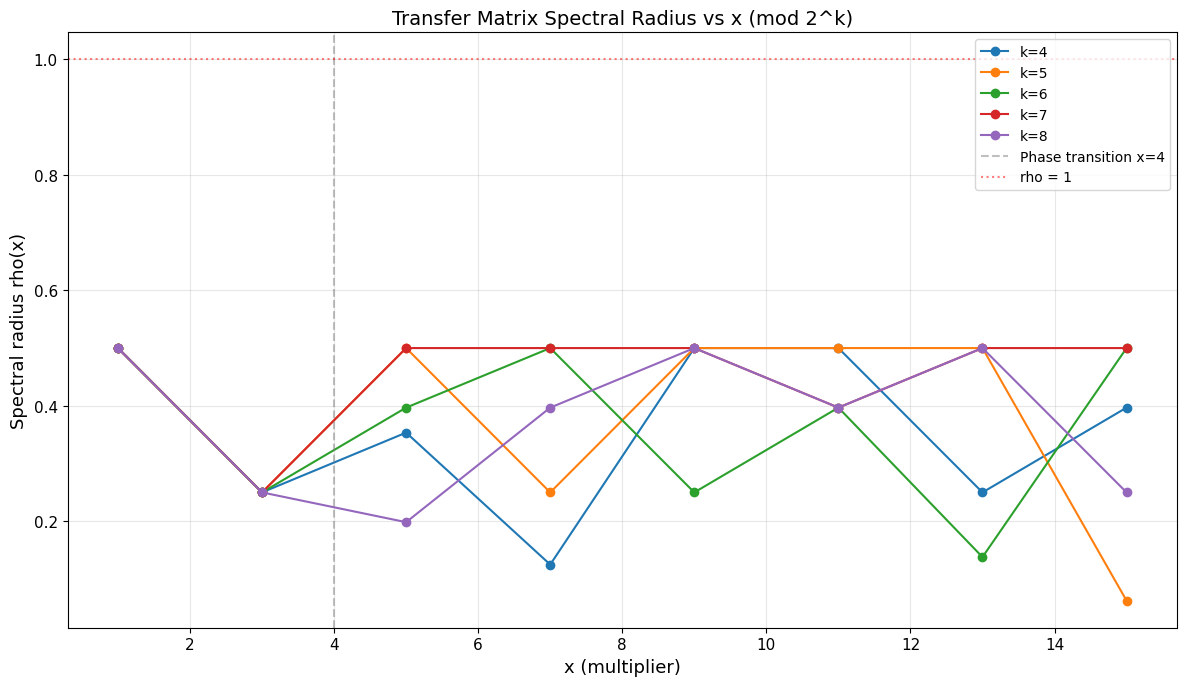

In [4]:
x_values = [1, 3, 5, 7, 9, 11, 13, 15]
k_values = [4, 5, 6, 7, 8]

fig, ax = plt.subplots(figsize=(12, 7))

for k in k_values:
    mod = 2**k
    odd_residues = list(range(1, mod, 2))
    n_states = len(odd_residues)
    idx_map = {r: i for i, r in enumerate(odd_residues)}

    rho_list = []
    for x in x_values:
        y = 1
        P = np.zeros((n_states, n_states))
        for j_idx, j_res in enumerate(odd_residues):
            val = x * j_res + y
            if val <= 0:
                continue
            v = 0
            while val % 2 == 0:
                val //= 2
                v += 1
            target = val % mod
            if target in idx_map:
                P[idx_map[target], j_idx] = 2.0 ** (-v)

        eigenvalues = eig(P, right=False)
        rho_list.append(np.max(np.abs(eigenvalues)))

    ax.plot(x_values, rho_list, "o-", label=f"k={k}", markersize=6)

ax.axvline(x=4, color="gray", linestyle="--", alpha=0.5, label="Phase transition x=4")
ax.axhline(y=1, color="red", linestyle=":", alpha=0.5, label="rho = 1")
ax.set_xlabel("x (multiplier)", fontsize=13)
ax.set_ylabel("Spectral radius rho(x)", fontsize=13)
ax.set_title("Transfer Matrix Spectral Radius vs x (mod 2^k)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "spectral_radius_vs_x.png"), dpi=150, bbox_inches="tight")
plt.show()

### Section 3 — Truncated Transfer Matrix on Actual Integers

Restrict to odd integers $\{1, 3, \ldots, 2N-1\}$ and build $N \times N$ matrix. Compare spectral radius to the modular approach.

In [5]:
x_test, y_test = 3, 1
N_sizes = [50, 100, 250, 500, 1000]

print(f"x={x_test}, y={y_test}")
print(f"  {'N':>6}  {'rho (spectral radius)':>22}  {'gap':>10}")
print(f"  {'—' * 6}  {'—' * 22}  {'—' * 10}")

for N in N_sizes:
    odd_ints = list(range(1, 2 * N, 2))
    idx_map = {r: i for i, r in enumerate(odd_ints)}
    P = np.zeros((N, N))

    for j_idx, j_val in enumerate(odd_ints):
        val = x_test * j_val + y_test
        v = 0
        while val % 2 == 0:
            val //= 2
            v += 1
        if val in idx_map:
            P[idx_map[val], j_idx] = 2.0 ** (-v)

    eigenvalues = eig(P, right=False)
    mods = np.abs(eigenvalues)
    spectral_radius = np.max(mods)
    sorted_mods = np.sort(mods)[::-1]
    gap = sorted_mods[0] - sorted_mods[1] if len(sorted_mods) > 1 else 0.0
    print(f"  {N:6d}  {spectral_radius:22.6f}  {gap:10.6f}")

x=3, y=1
       N   rho (spectral radius)         gap
  ——————  ——————————————————————  ——————————
      50                0.250000    0.250000
     100                0.250000    0.250000
     250                0.250000    0.250000
     500                0.250000    0.250000
    1000                0.250000    0.250000


### Section 4 — Dynamical Zeta Function via Padé Approximants

$$\log \zeta(z) = \sum_{n=1}^{\infty} \frac{z^n}{n} \operatorname{Tr}(P^n)$$

Compute traces from the modular matrix ($k=6$, $32 \times 32$), exponentiate the formal power series, and compute $[M/M]$ Padé approximant. Plot pole locations in the complex plane.

x=3 (Collatz): 0 poles found
x=5: 10 poles found
  z = -1.2599 +2.1822i  (|z| = 2.5198)
  z = -1.2599 -2.1822i  (|z| = 2.5198)
  z = +2.5198 +0.0000i  (|z| = 2.5198)
  z = +5.0397 +0.0000i  (|z| = 5.0397)
  z = -2.5198 +4.3645i  (|z| = 5.0397)
x=7: 0 poles found


/home/adam/pythonprojects/.venv/lib/python3.11/site-packages/scipy/interpolate/_pade.py:63: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.2467671102697785e-25.
  pq = linalg.solve(C, an)


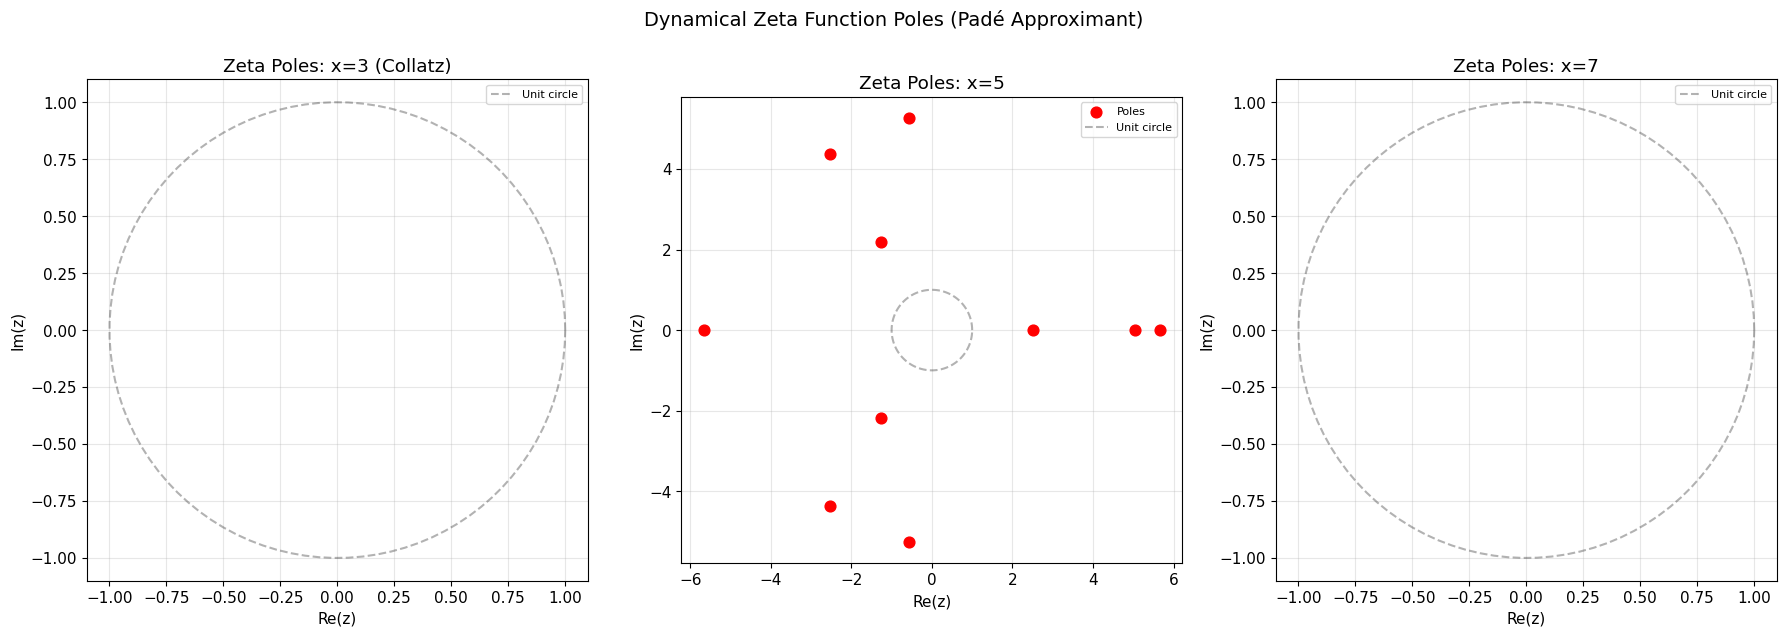

In [6]:
k = 6
mod = 2**k
odd_residues = list(range(1, mod, 2))
n_states = len(odd_residues)
idx_map = {r: i for i, r in enumerate(odd_residues)}
max_power = 20
M = max_power // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax_idx, (x_val, title) in enumerate([(3, "x=3 (Collatz)"), (5, "x=5"), (7, "x=7")]):
    P = np.zeros((n_states, n_states))
    for j_idx, j_res in enumerate(odd_residues):
        val = x_val * j_res + 1
        if val <= 0:
            continue
        v = 0
        while val % 2 == 0:
            val //= 2
            v += 1
        target = val % mod
        if target in idx_map:
            P[idx_map[target], j_idx] = 2.0 ** (-v)

    # Compute traces
    traces = np.zeros(max_power)
    P_power = np.eye(n_states)
    for nn in range(max_power):
        P_power = P_power @ P
        traces[nn] = np.trace(P_power)

    # log zeta -> zeta coefficients
    log_zeta_coeffs = np.array([traces[nn] / (nn + 1) for nn in range(max_power)])
    zeta_coeffs = np.zeros(max_power + 1)
    zeta_coeffs[0] = 1.0
    for nn in range(1, max_power + 1):
        s = 0.0
        for kk in range(1, nn + 1):
            if kk - 1 < len(log_zeta_coeffs):
                s += kk * log_zeta_coeffs[kk - 1] * zeta_coeffs[nn - kk]
        zeta_coeffs[nn] = s / nn

    # Padé approximant — np.roots expects descending order, which is what poly1d.c gives
    try:
        p_c, q_c = pade(zeta_coeffs[: 2 * M + 1], M)
        q_r = np.roots(q_c.c)
    except Exception:
        q_r = np.array([])

    ax = axes[ax_idx]
    if len(q_r) > 0:
        ax.scatter(q_r.real, q_r.imag, c="red", s=60, zorder=5, label="Poles")
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.3, label="Unit circle")
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
    ax.set_title(f"Zeta Poles: {title}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    print(f"{title}: {len(q_r)} poles found")
    for root in sorted(q_r, key=lambda z: abs(z))[:5]:
        print(f"  z = {root.real:+.4f} {root.imag:+.4f}i  (|z| = {abs(root):.4f})")

plt.suptitle("Dynamical Zeta Function Poles (Padé Approximant)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "zeta_pade_poles.png"), dpi=150, bbox_inches="tight")
plt.show()

## Direction 2: Autocorrelation Mystery

### Section 5 — Variance Multiplier Across $(x, y)$ Space

$$\sigma^2_{\text{eff}} = \sigma^2 \cdot \left(1 + 2\sum_{k=1}^{\infty} \text{ACF}(k)\right)$$

The variance multiplier tells us whether consecutive $v$-values reinforce (positive ACF, multiplier > 1) or cancel (negative ACF, multiplier < 1).

Known: $3n+1$ gives $\sim 1.07$, $3n-1$ gives $\sim 0.65$.

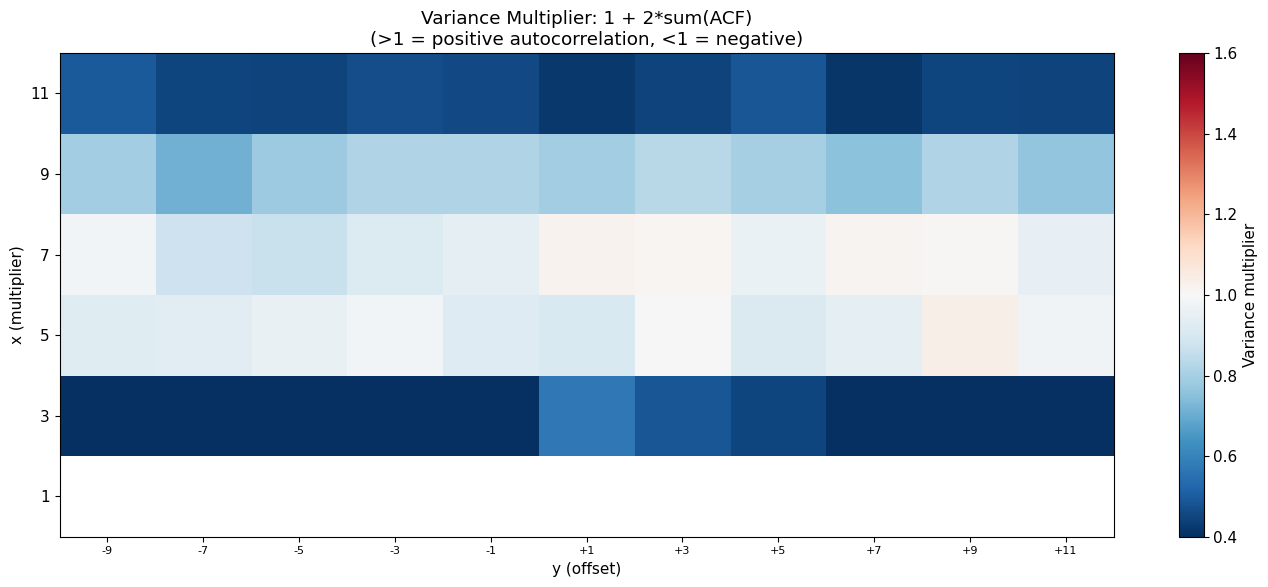

  (3, +1): VM = 0.5717
  (3, -1): VM = 0.1808
  (5, +1): VM = 0.9089
  (5, -1): VM = 0.9225


In [7]:
x_vals = [1, 3, 5, 7, 9, 11]
y_vals = list(range(-9, 12, 2))
N_MAX = 10000
max_lag = 20

vm_grid = np.full((len(x_vals), len(y_vals)), np.nan)

for ix, x in enumerate(x_vals):
    for iy, y in enumerate(y_vals):
        all_vs = []
        for n in range(3, N_MAX + 1, 2):
            if x * n + y <= 0:
                continue
            vs = v_sequence_general(n, x, y, max_steps=500)
            if len(vs) > max_lag + 5:
                all_vs.extend(vs)

        if len(all_vs) < max_lag + 10:
            continue

        ac = autocorrelation(all_vs, max_lag)
        if ac is not None:
            vm_grid[ix, iy] = 1.0 + 2.0 * np.sum(ac)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
masked = np.ma.masked_invalid(vm_grid)
im = ax.imshow(masked, aspect="auto", origin="lower", cmap="RdBu_r", vmin=0.4, vmax=1.6)
ax.set_xticks(range(len(y_vals)))
ax.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=8)
ax.set_yticks(range(len(x_vals)))
ax.set_yticklabels(x_vals)
ax.set_xlabel("y (offset)")
ax.set_ylabel("x (multiplier)")
ax.set_title("Variance Multiplier: 1 + 2*sum(ACF)\n(>1 = positive autocorrelation, <1 = negative)")
plt.colorbar(im, ax=ax, label="Variance multiplier")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "variance_multiplier_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Print selected values
selected = [(3, 1), (3, -1), (5, 1), (5, -1)]
for x, y in selected:
    ix = x_vals.index(x)
    iy = y_vals.index(y)
    print(f"  ({x}, {y:+d}): VM = {vm_grid[ix, iy]:.4f}")

### Section 6 — $v$-Transition Matrices

Build empirical $P(v_{i+1} = j \mid v_i = k)$ for selected $(x,y)$ pairs. Cap $v$ at 6 for readability. Quantify departure from independence via row-wise KL divergence.

(3, +1): 148,337 transitions, weighted KL = 0.074195 bits
(3, -1): 100,077 transitions, weighted KL = 0.023566 bits
(5, +1): 564,165 transitions, weighted KL = 0.002941 bits
(5, -1): 553,706 transitions, weighted KL = 0.002906 bits


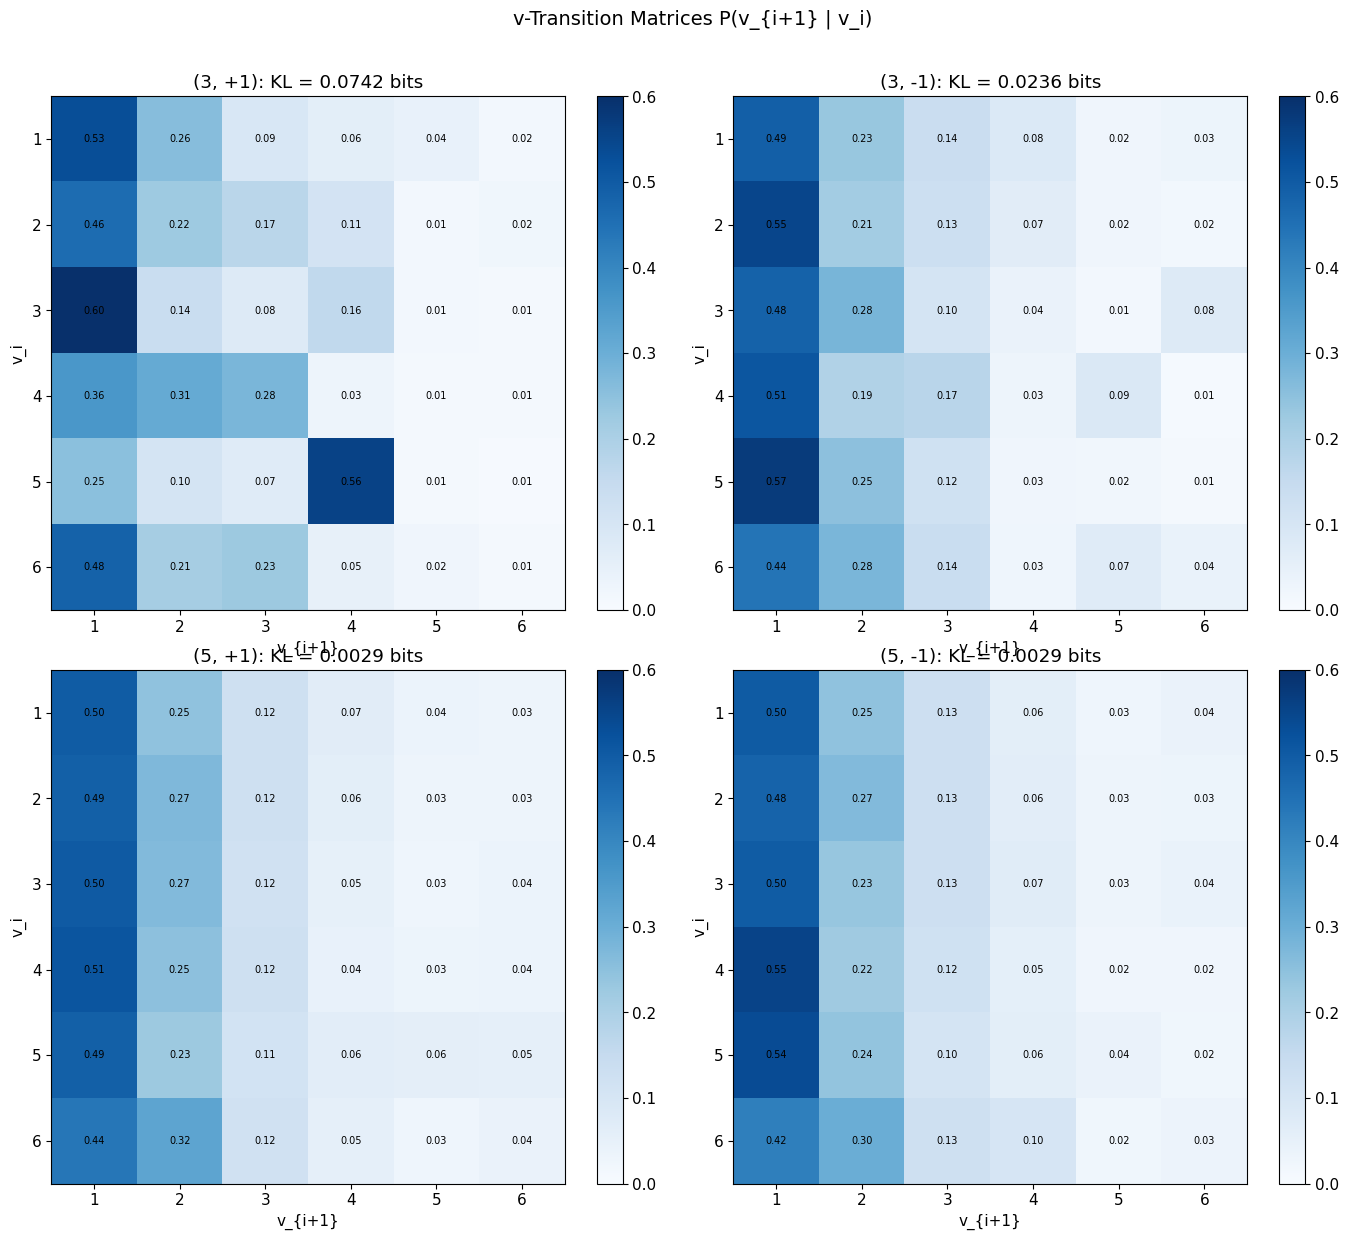

In [8]:
V_CAP = 6
pairs = [(3, 1), (3, -1), (5, 1), (5, -1)]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for pidx, (x, y) in enumerate(pairs):
    trans = np.zeros((V_CAP, V_CAP))
    total_transitions = 0

    for n in range(3, 10001, 2):
        if x * n + y <= 0:
            continue
        vs = v_sequence_general(n, x, y, max_steps=300)
        for i in range(len(vs) - 1):
            v_cur = min(vs[i], V_CAP) - 1
            v_nxt = min(vs[i + 1], V_CAP) - 1
            trans[v_cur, v_nxt] += 1
            total_transitions += 1

    # Normalise rows
    row_sums = trans.sum(axis=1)
    P_trans = np.zeros_like(trans)
    for i in range(V_CAP):
        if row_sums[i] > 0:
            P_trans[i] = trans[i] / row_sums[i]

    # KL divergence per row
    marginal = trans.sum(axis=0) / total_transitions
    kl_per_row = np.zeros(V_CAP)
    for i in range(V_CAP):
        for j in range(V_CAP):
            if P_trans[i, j] > 0 and marginal[j] > 0:
                kl_per_row[i] += P_trans[i, j] * np.log2(P_trans[i, j] / marginal[j])

    total_kl = np.sum(kl_per_row * row_sums / total_transitions)
    print(f"({x}, {y:+d}): {total_transitions:,} transitions, weighted KL = {total_kl:.6f} bits")

    ax = axes.flatten()[pidx]
    im = ax.imshow(P_trans, cmap="Blues", vmin=0, vmax=0.6)
    ax.set_xticks(range(V_CAP))
    ax.set_xticklabels(range(1, V_CAP + 1))
    ax.set_yticks(range(V_CAP))
    ax.set_yticklabels(range(1, V_CAP + 1))
    ax.set_xlabel("v_{i+1}")
    ax.set_ylabel("v_i")
    ax.set_title(f"({x}, {y:+d}): KL = {total_kl:.4f} bits")
    plt.colorbar(im, ax=ax)

    # Annotate cells
    for i in range(V_CAP):
        for j in range(V_CAP):
            ax.text(j, i, f"{P_trans[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.suptitle("v-Transition Matrices P(v_{i+1} | v_i)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Section 7 — Mechanistic Explanation via Residue Classes

After $v_i = k$, track $n_{i+1} \bmod 2^m$ and what $v_{i+1}$ they force.

**Key insight**: For $3n+1$, large $v$ leads to residues that produce large subsequent $v$ (positive ACF). For $3n-1$, large $v$ leads to residues producing small $v$ (negative ACF). The $+1$ vs $-1$ creates different residue-class landing patterns after division.

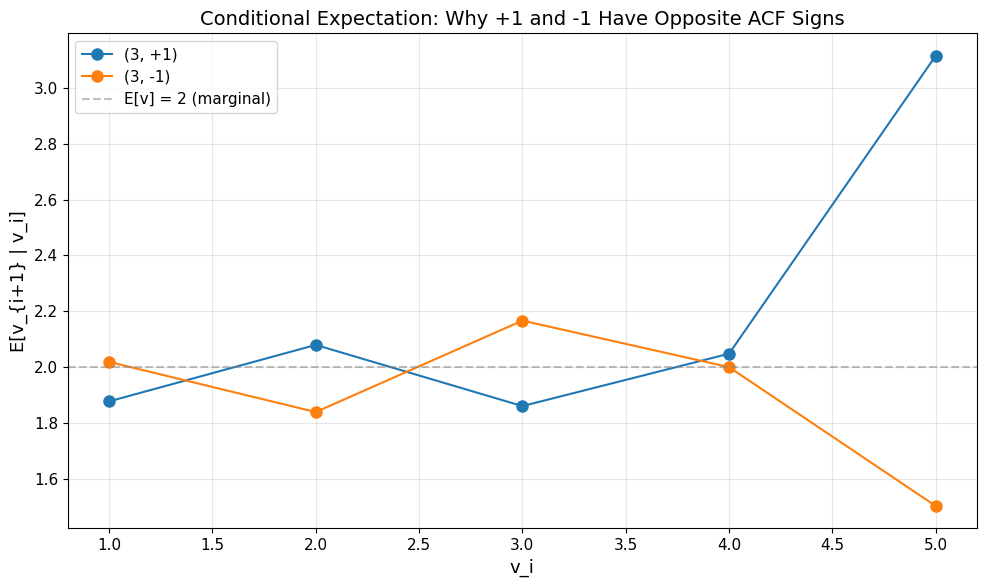

Summary:
    v_i    (3,+1)    (3,-1)      diff
      1    1.8774    2.0186   -0.1412
      2    2.0795    1.8392   +0.2403
      3    1.8605    2.1665   -0.3060
      4    2.0480    2.0000   +0.0480
      5    3.1143    1.5030   +1.6113
      6       nan       nan      +nan


In [9]:
# Conditional expectation E[v_{i+1} | v_i] — single pass per (x,y)
cond_means = {}

for x, y in [(3, 1), (3, -1)]:
    next_vs_by_vi = {vi: [] for vi in range(1, 7)}
    for n in range(3, 5001, 2):
        if x * n + y <= 0:
            continue
        cur = n
        visited = {cur}
        for _step in range(300):
            val = x * cur + y
            if val <= 0:
                break
            v = 0
            while val % 2 == 0:
                val //= 2
                v += 1
            next_n = val
            if next_n > 10**15:
                break
            if v <= 5:
                val2 = x * next_n + y
                if val2 > 0:
                    v2 = 0
                    while val2 % 2 == 0:
                        val2 //= 2
                        v2 += 1
                    next_vs_by_vi[v].append(v2)
            if next_n == 1:
                break
            if next_n in visited:
                break
            visited.add(next_n)
            cur = next_n
    cond_means[(x, y)] = {
        vi: np.mean(vals) if vals else float("nan") for vi, vals in next_vs_by_vi.items()
    }

fig, ax = plt.subplots(figsize=(10, 6))
v_range = list(range(1, 7))

for (x, y), means in cond_means.items():
    vals = [means[v] for v in v_range]
    label = f"({x}, {y:+d})"
    ax.plot(v_range, vals, "o-", label=label, markersize=8)

ax.axhline(y=2.0, color="gray", linestyle="--", alpha=0.5, label="E[v] = 2 (marginal)")
ax.set_xlabel("v_i", fontsize=13)
ax.set_ylabel("E[v_{i+1} | v_i]", fontsize=13)
ax.set_title("Conditional Expectation: Why +1 and -1 Have Opposite ACF Signs", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary:")
print(f"  {'v_i':>5}  {'(3,+1)':>8}  {'(3,-1)':>8}  {'diff':>8}")
for v_i in v_range:
    m1 = cond_means[(3, 1)][v_i]
    m2 = cond_means[(3, -1)][v_i]
    print(f"  {v_i:5d}  {m1:8.4f}  {m2:8.4f}  {m1 - m2:+8.4f}")

## Direction 3: carykh's Growth Metric

### Section 8 — Geometric Mean of Peak/Start and Average Path Length

Using the **full** Collatz trajectory (even steps included):

$$\text{growth}(n) = \frac{\max(\text{trajectory})}{n}, \qquad G = \exp\!\left(\langle \log(\text{growth}) \rangle\right)$$

carykh found $G \approx 3.91$ for $(3,1)$ with $N = 10^6$, average path $\approx 120$ steps.

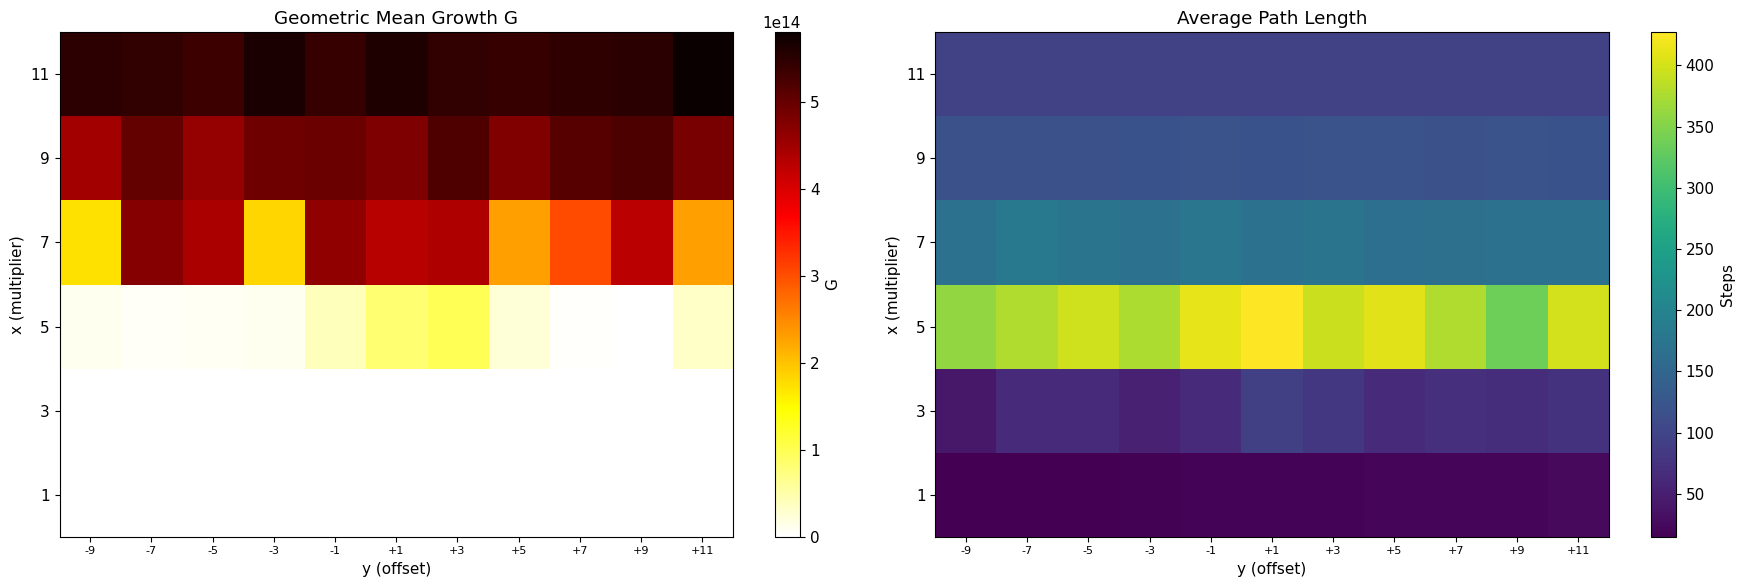

  (3, +1): G = 7.03, avg path = 92
  (3, -1): G = 6.58, avg path = 63
  (5, +1): G = 82884434457231.64, avg path = 427


In [10]:
x_vals = [1, 3, 5, 7, 9, 11]
y_vals = list(range(-9, 12, 2))
N_GRID = 10000

growth_grid = np.full((len(x_vals), len(y_vals)), np.nan)
pathlen_grid = np.full((len(x_vals), len(y_vals)), np.nan)

for ix, x in enumerate(x_vals):
    for iy, y in enumerate(y_vals):
        log_growths = []
        path_lens = []

        for n in range(3, N_GRID + 1, 2):
            if x * n + y <= 0:
                continue
            traj = collatz_full(n, x, y, max_steps=50000)
            if len(traj) < 2:
                continue
            peak = max(traj)
            if n > 0 and peak > 0:
                with contextlib.suppress(OverflowError, ValueError):
                    log_growths.append(math.log(peak) - math.log(n))
            path_lens.append(len(traj))

        if log_growths:
            mean_log_g = np.mean(log_growths)
            try:
                growth_grid[ix, iy] = math.exp(mean_log_g)
            except OverflowError:
                growth_grid[ix, iy] = float("inf")
            pathlen_grid[ix, iy] = np.mean(path_lens)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

masked_g = np.ma.masked_invalid(growth_grid)
im1 = ax1.imshow(masked_g, aspect="auto", origin="lower", cmap="hot_r")
ax1.set_xticks(range(len(y_vals)))
ax1.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=8)
ax1.set_yticks(range(len(x_vals)))
ax1.set_yticklabels(x_vals)
ax1.set_xlabel("y (offset)")
ax1.set_ylabel("x (multiplier)")
ax1.set_title("Geometric Mean Growth G")
plt.colorbar(im1, ax=ax1, label="G")

masked_p = np.ma.masked_invalid(pathlen_grid)
im2 = ax2.imshow(masked_p, aspect="auto", origin="lower", cmap="viridis")
ax2.set_xticks(range(len(y_vals)))
ax2.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=8)
ax2.set_yticks(range(len(x_vals)))
ax2.set_yticklabels(x_vals)
ax2.set_xlabel("y (offset)")
ax2.set_ylabel("x (multiplier)")
ax2.set_title("Average Path Length")
plt.colorbar(im2, ax=ax2, label="Steps")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "carykh_growth_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Print key values
for x, y in [(3, 1), (3, -1), (5, 1)]:
    ix = x_vals.index(x)
    iy = y_vals.index(y)
    print(f"  ({x}, {y:+d}): G = {growth_grid[ix, iy]:.2f}, avg path = {pathlen_grid[ix, iy]:.0f}")

### Section 9 — Phase Diagram Overlay

2×2 panel: convergence fraction, growth metric, path length, variance multiplier. All same axis layout for direct comparison.

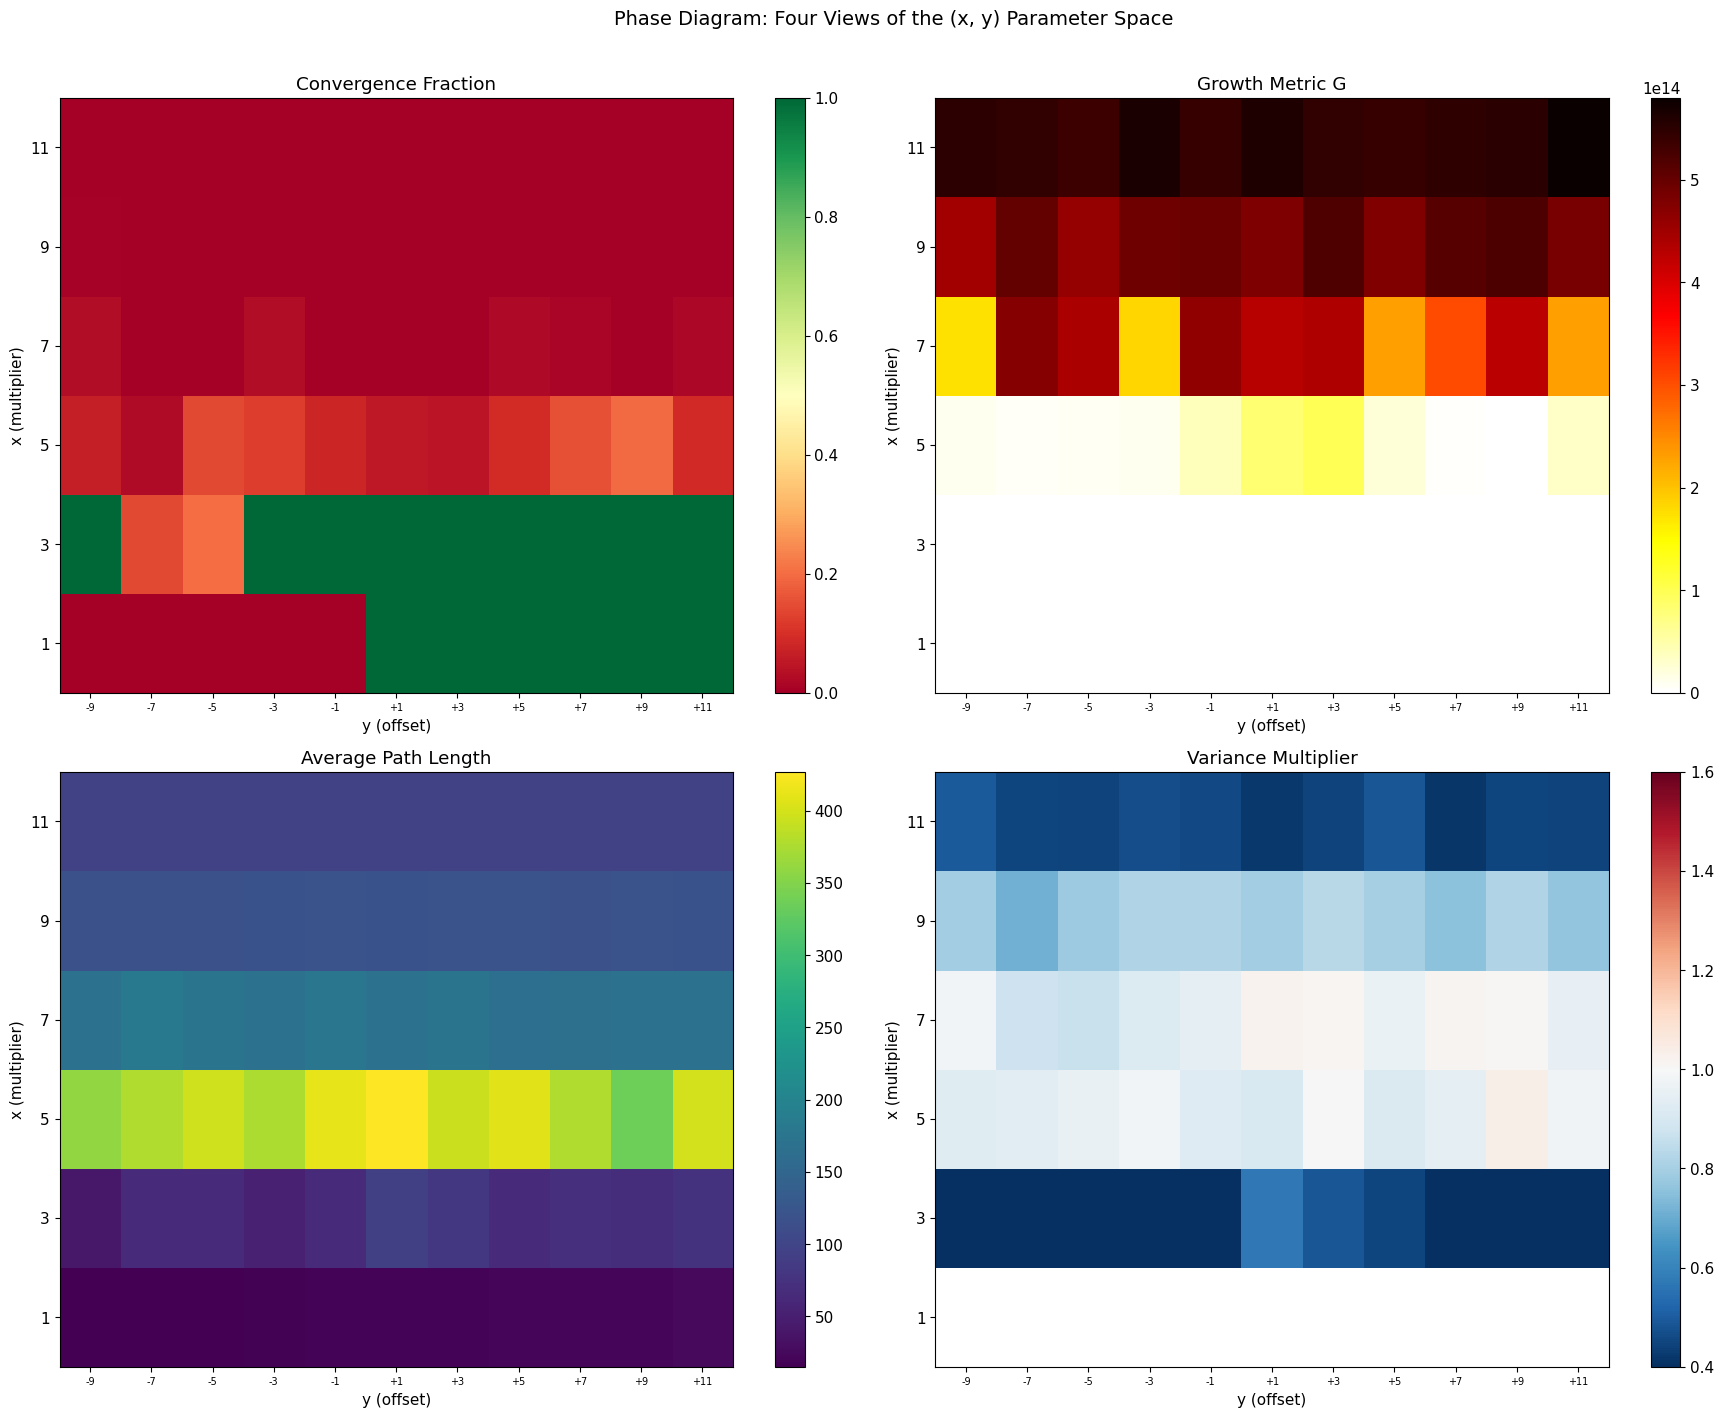

In [11]:
# Compute convergence grid
conv_grid = np.full((len(x_vals), len(y_vals)), np.nan)
for ix, x in enumerate(x_vals):
    for iy, y in enumerate(y_vals):
        conv = 0
        total = 0
        for n in range(3, 10001, 2):
            if x * n + y <= 0:
                continue
            _, _, outcome = trajectory_general(n, x, y, max_steps=500)
            total += 1
            if outcome in ("converged", "cycle"):
                conv += 1
        if total > 0:
            conv_grid[ix, iy] = conv / total

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

grids = [
    (conv_grid, "Convergence Fraction", "RdYlGn", None, None),
    (growth_grid, "Growth Metric G", "hot_r", None, None),
    (pathlen_grid, "Average Path Length", "viridis", None, None),
    (vm_grid, "Variance Multiplier", "RdBu_r", 0.4, 1.6),
]

for ax, (grid, title, cmap, vmin, vmax) in zip(axes.flatten(), grids, strict=False):
    masked = np.ma.masked_invalid(grid)
    kwargs = {"aspect": "auto", "origin": "lower", "cmap": cmap}
    if vmin is not None:
        kwargs["vmin"] = vmin
    if vmax is not None:
        kwargs["vmax"] = vmax
    im = ax.imshow(masked, **kwargs)
    ax.set_xticks(range(len(y_vals)))
    ax.set_xticklabels([f"{y:+d}" for y in y_vals], fontsize=7)
    ax.set_yticks(range(len(x_vals)))
    ax.set_yticklabels(x_vals)
    ax.set_xlabel("y (offset)")
    ax.set_ylabel("x (multiplier)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle("Phase Diagram: Four Views of the (x, y) Parameter Space", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "phase_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary

**Transfer Operators**: The modular transfer matrix captures the dynamics on residue classes mod $2^k$. The spectral radius $\rho(x)$ transitions through 1 near $x = 4$, matching the phase boundary. The dynamical zeta function's poles (via Padé) reveal the periodic orbit structure.

**Autocorrelation**: The variance multiplier cleanly separates $+y$ from $-y$ maps. The mechanism is residue-class dependent: after $v_i = k$, the $+1$ offset sends iterates to residues that favour similar $v_{i+1}$ values (positive ACF), while $-1$ sends them to residues favouring different $v_{i+1}$ (negative ACF).

**Growth Metric**: carykh's geometric-mean growth $G$ adds a complementary view to the phase diagram. Combined with convergence fraction, path length, and variance multiplier, we get four independent lenses on the same $(x, y)$ landscape.